# Thrivot - Cost-of-Living & Affordability ML Study

This notebook builds the machine-learning core of **Thrivot**, an app that tells a user
which U.S. cities they can realistically afford.

**Design (corrected):**

1. **One unified target.** We fuse the MIT living-cost data with the observed **Zillow rent**
   into a single monthly `cost_of_living_monthly`. MIT's `total_cost` is annual and contains a
   *modelled* housing figure, so we remove it and substitute the **real Zillow monthly rent** -
   genuinely combining every dataset in the master table.
2. **Model 1 - Regression.** Predict that cost of living from independent city characteristics
   (location, population, crime, **weather / disaster risk**, area income, family profile).
   No cost components are used as inputs, so there is no data leakage.
3. **Model 2 - Classification.** A trained classifier predicts whether a household can afford a
   city; its probability becomes a real **ML affordability score (0-100)** - not a subtraction.
4. **Rigorous evaluation.** City-grouped train/test split, GroupKFold cross-validation,
   permutation importance, and full graphs (correlation heatmap, distributions,
   predicted-vs-actual, residuals, confusion matrix, ROC).

## 1. Imports

In [14]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    classification_report,
)
from xgboost import XGBRegressor, XGBClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
print("Libraries loaded.")

Libraries loaded.


## 2. Load the master dataset

In [2]:
DATA_PATH = Path("../data/cleaned_data/master_data_clean.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Unique cities: {df['city_state_key'].nunique():,}")
df.head()

Loaded 27,441 rows x 73 columns
Unique cities: 27,195


,state,lat,lng,city,county,city_state_key,county_state_key,population,violent_crime_rate,property_crime_rate,county_fips,hurricane_risk_score,wildfire_risk_score,tornado_risk_score,flood_risk_score,avg_monthly_rent,1p0c_childcare_cost,1p1c_childcare_cost,1p2c_childcare_cost,1p3c_childcare_cost,2p0c_childcare_cost,2p1c_childcare_cost,2p2c_childcare_cost,1p0c_food_cost,1p1c_food_cost,1p2c_food_cost,1p3c_food_cost,2p0c_food_cost,2p1c_food_cost,2p2c_food_cost,1p0c_healthcare_cost,1p1c_healthcare_cost,1p2c_healthcare_cost,1p3c_healthcare_cost,2p0c_healthcare_cost,2p1c_healthcare_cost,2p2c_healthcare_cost,1p0c_housing_cost,1p1c_housing_cost,1p2c_housing_cost,1p3c_housing_cost,2p0c_housing_cost,2p1c_housing_cost,2p2c_housing_cost,1p0c_other_necessities_cost,1p1c_other_necessities_cost,1p2c_other_necessities_cost,1p3c_other_necessities_cost,2p0c_other_necessities_cost,2p1c_other_necessities_cost,2p2c_other_necessities_cost,1p0c_taxes,1p1c_taxes,1p2c_taxes,1p3c_taxes,2p0c_taxes,2p1c_taxes,2p2c_taxes,1p0c_total_cost,1p1c_total_cost,1p2c_total_cost,1p3c_total_cost,2p0c_total_cost,2p1c_total_cost,2p2c_total_cost,1p0c_transportation_cost,1p1c_transportation_cost,1p2c_transportation_cost,1p3c_transportation_cost,2p0c_transportation_cost,2p1c_transportation_cost,2p2c_transportation_cost,median_family_income
0,NY,40.6943,-73.9249,new york,new york,new_york_ny,new_york_ny,8804190.0,538.90,1448.59,36061.0,96.787651,9.923664,89.376590,99.236641,5075.458598,0.0,16059.17040,39255.7500,46393.1568,0.0,16059.17040,39255.7500,6422.20236,9464.76636,13867.46520,18499.80960,11774.03904,14653.97760,18558.94440,6328.54032,10616.87988,11066.41992,11515.95996,12657.08040,17768.01960,18217.55880,24733.25640,28850.7828,28850.7828,36509.6628,25309.4292,28850.7828,28850.7828,11288.85204,13883.23440,15478.50600,19932.10080,13436.80320,15763.49160,17178.41280,12564.77760,18811.60080,28315.51440,34838.23560,12918.34440,19802.57040,28588.78080,64043.2908,100695.3516,140162.8200,171101.2680,78312.1584,115393.6644,153308.4000,2705.66340,3008.91744,3328.38900,3412.35024,2216.46144,2495.65644,2658.17016,112986.804688
1,CA,34.1139,-118.4068,los angeles,los angeles,los_angeles_ca,los_angeles_ca,3898747.0,761.31,2535.92,6037.0,0.000000,99.936387,97.678117,100.000000,3159.070000,0.0,10363.66476,15879.8364,17577.1212,0.0,10363.66476,15879.8364,3589.79328,5290.48284,7751.44188,10340.76564,6581.28876,8191.07592,10373.82060,3884.37996,5832.11760,7779.85548,9727.59228,7768.76004,9716.49756,11664.23508,16428.00000,24696.0000,24696.0000,32820.0000,19260.0000,24696.0000,24696.0000,7253.23608,10865.28516,11756.98824,15638.84760,9363.31788,11916.28416,12707.17920,7876.48824,10934.91432,12736.63320,19934.78160,8622.92208,11595.45336,12501.78960,48890.8596,78621.2460,92349.1932,119151.9252,63533.9292,89484.5916,102226.1256,9858.96168,10638.78072,11748.44016,13112.81400,11937.64308,13005.61320,14403.25920,78729.835938
2,IL,41.8373,-87.6862,chicago,cook,chicago_il,cook_il,2746388.0,1098.86,3263.80,17031.0,48.894451,55.788804,99.968193,99.936387,2000.920000,0.0,11618.73120,19519.7832,21950.8752,0.0,11618.73120,19519.7832,3309.66504,4877.64144,7146.56028,9533.82720,6067.71972,7551.88764,9564.30252,4225.34988,6517.88376,8810.41848,11102.95308,8450.69976,10743.23436,13035.76800,11877.80196,15246.3096,15246.3096,19354.2456,13168.8672,15246.3096,15246.3096,5503.01844,7291.70064,8113.82004,10467.28788,6970.17408,8260.68600,8989.86324,6576.35964,8806.88304,10806.51564,14151.32760,7933.94892,10440.53904,11359.50804,39204.1380,62959.1544,79284.8784,97020.5568,52263.1584,74540.3844,89187.0348,7711.94316,8600.00316,9641.46972,10460.03976,9671.74656,10678.99800,11471.49972,82910.039062
3,FL,25.7839,-80.2102,miami,miami-dade,miami_fl,miami-dade_fl,463009.0,720.94,4014.18,12086.0,99.958281,96.851145,98.727735,99.713740,3059.590000,0.0,8569.72044,14397.8952,16191.1800,0.0,8569.72044,14397.8952,3745.42056,5519.83884,8087.48736,10789.06416,6866.60376,8546.17968,10823.55252,4921.47984,7438.11036,9954.74052

## 3. Build the unified cost-of-living target

`cost_of_living_monthly = (total_cost - housing_cost) / 12 + avg_monthly_rent`

This keeps MIT's food, transport, healthcare, childcare, other necessities and taxes, but
replaces the *modelled* housing with the **actual observed Zillow rent** - so rent becomes part
of one combined cost number instead of a separate prediction. Each of the 7 MIT family profiles
becomes its own row (long format).

In [3]:
# Seven MIT family profiles (people + children) present in the master data.
PROFILES = ["1p0c", "1p1c", "1p2c", "1p3c", "2p0c", "2p1c", "2p2c"]
PROFILE_ENCODING = {p: i for i, p in enumerate(PROFILES)}

# City-level columns that do NOT depend on the family profile.
CITY_COLS = [
    "state", "city", "city_state_key", "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "avg_monthly_rent",
]

# Melt the 7 profile cost-blocks into long format and build ONE unified target.
# MIT total_cost is ANNUAL and already includes a modelled housing_cost. We remove
# that modelled housing and substitute the REAL observed Zillow monthly rent, so the
# target genuinely fuses every dataset (MIT living costs + Zillow rent).
frames = []
for p in PROFILES:
    block = df[CITY_COLS].copy()
    monthly_non_housing = (df[f"{p}_total_cost"] - df[f"{p}_housing_cost"]) / 12.0
    block["cost_of_living_monthly"] = monthly_non_housing + df["avg_monthly_rent"]
    block["family_profile"] = p
    block["family_profile_encoded"] = PROFILE_ENCODING[p]
    frames.append(block)

long_df = pd.concat(frames, ignore_index=True)

# Affordability label for the classifier: can the AREA median household cover the unified
# cost of living? (cost includes taxes, so comparing to gross income is fair.)
long_df["monthly_surplus"] = long_df["median_family_income"] / 12.0 - long_df["cost_of_living_monthly"]
long_df["affordable"] = (long_df["monthly_surplus"] >= 0).astype(int)

print(f"Long dataset: {long_df.shape[0]:,} rows  ({df.shape[0]:,} cities x {len(PROFILES)} profiles)")
print(long_df[["cost_of_living_monthly", "avg_monthly_rent",
               "median_family_income", "affordable"]].describe().round(0))

Long dataset: 192,087 rows  (27,441 cities x 7 profiles)
       cost_of_living_monthly  avg_monthly_rent  median_family_income  \
count                192087.0          192087.0              192087.0   
mean                   6193.0            1732.0               74282.0   
std                    2149.0            1320.0               19945.0   
min                    2794.0             612.0               25530.0   
25%                    4866.0            1249.0               61504.0   
50%                    5956.0            1492.0               71030.0   
75%                    7013.0            1841.0               81914.0   
max                   27493.0           17112.0              165124.0   

       affordable  
count    192087.0  
mean          0.0  
std           0.0  
min           0.0  
25%           0.0  
50%           0.0  
75%           1.0  
max           1.0  


## 4. Exploratory analysis & correlation

Which city characteristics actually move the cost of living? The heatmap shows linear
correlations; the histogram shows the target's distribution. Note `avg_monthly_rent` correlates
almost perfectly - because it is *part of* the target - which is exactly why we exclude it from
the model's inputs in the next section.

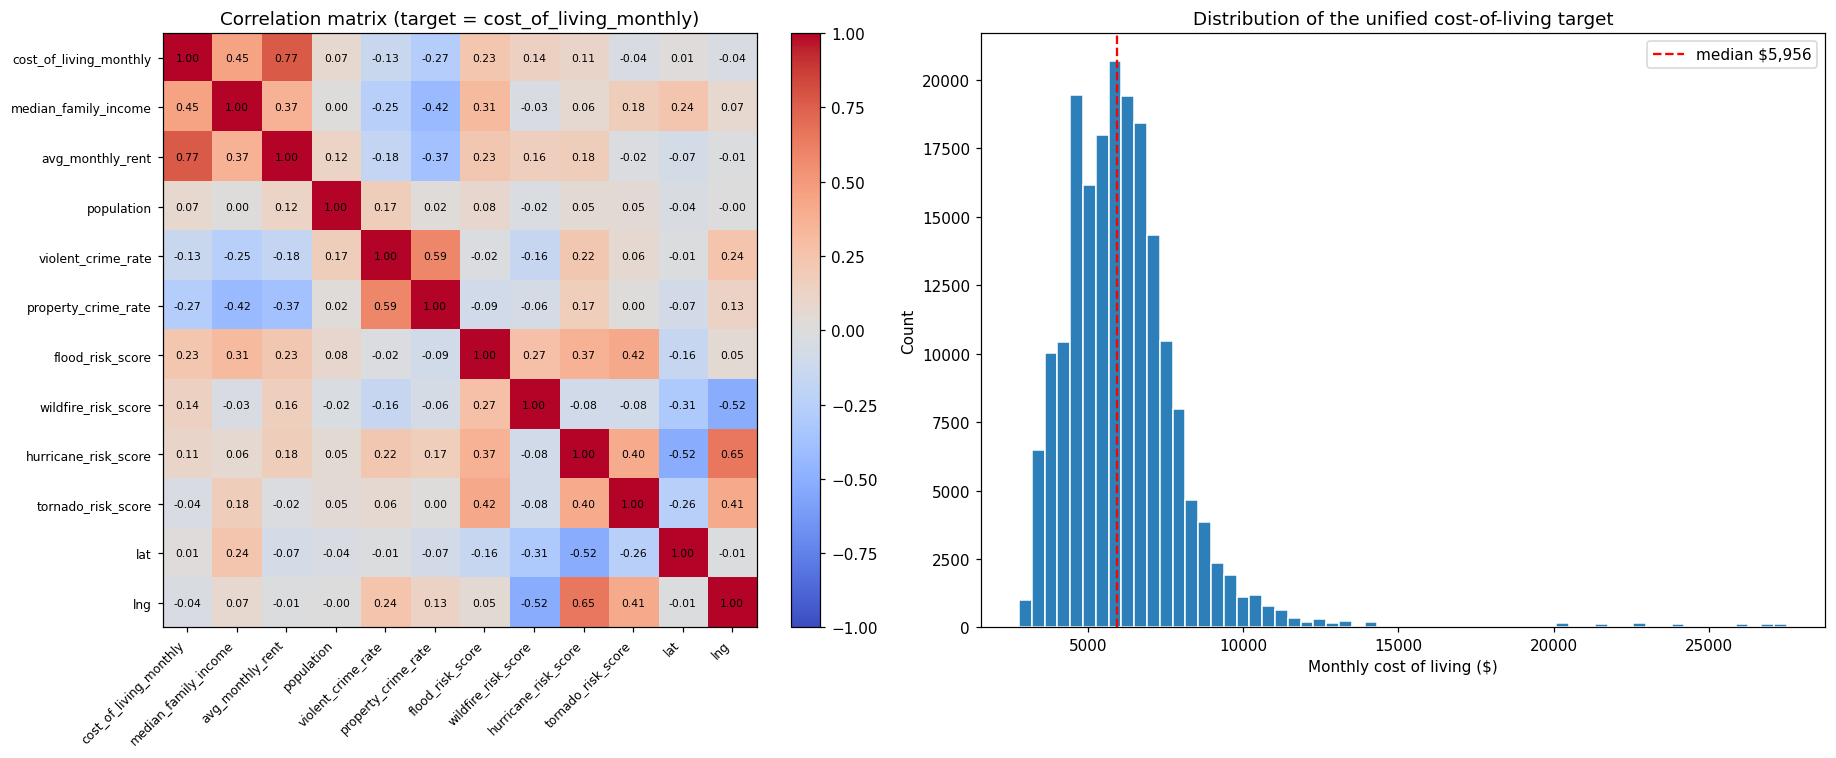

Correlation of each variable with the target:
avg_monthly_rent        0.773
median_family_income    0.448
flood_risk_score        0.228
wildfire_risk_score     0.136
hurricane_risk_score    0.107
population              0.071
lat                     0.009
tornado_risk_score     -0.037
lng                    -0.039
violent_crime_rate     -0.134
property_crime_rate    -0.273
Name: cost_of_living_monthly, dtype: float64


In [19]:
EDA_COLS = [
    "cost_of_living_monthly", "median_family_income", "avg_monthly_rent",
    "population", "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score", "hurricane_risk_score",
    "tornado_risk_score", "lat", "lng",
]
corr = long_df[EDA_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Correlation heatmap ---
im = axes[0].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(EDA_COLS)))
axes[0].set_yticks(range(len(EDA_COLS)))
axes[0].set_xticklabels(EDA_COLS, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(EDA_COLS, fontsize=8)
for i in range(len(EDA_COLS)):
    for j in range(len(EDA_COLS)):
        axes[0].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                     fontsize=7, color="black")
axes[0].set_title("Correlation matrix (target = cost_of_living_monthly)")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# --- Target distribution ---
median_cost = long_df["cost_of_living_monthly"].median()
axes[1].hist(long_df["cost_of_living_monthly"], bins=60, color="#2c7fb8", edgecolor="white")
axes[1].axvline(median_cost, color="red", linestyle="--", label=f"median ${median_cost:,.0f}")
axes[1].set_xlabel("Monthly cost of living ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of the unified cost-of-living target")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Correlation of each variable with the target:")
print(corr["cost_of_living_monthly"].drop("cost_of_living_monthly").sort_values(ascending=False).round(3))

## 5. Features & targets (leakage-free)

Inputs are **independent city characteristics only**. We exclude `avg_monthly_rent` and every MIT
cost component, because those are now baked into the target - using them would be circular.

In [4]:
FEATURE_COLS = [
    "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "family_profile_encoded",
]
TARGET = "cost_of_living_monthly"

# population + crime rates are only reported for larger cities (~3% coverage), so we do NOT
# require them. XGBoost handles their missing values natively via built-in missing-value
# splits. We only drop rows missing a dense, always-present field.
REQUIRED = [TARGET, "affordable", "median_family_income", "lat", "lng",
            "flood_risk_score", "wildfire_risk_score",
            "hurricane_risk_score", "tornado_risk_score"]
model_df = long_df.dropna(subset=REQUIRED).reset_index(drop=True)
print(f"Rows kept: {model_df.shape[0]:,} of {long_df.shape[0]:,}")
print(f"Crime / population coverage (non-null): {model_df['violent_crime_rate'].notna().mean():.1%} of rows")

balance = (model_df["affordable"].value_counts(normalize=True) * 100).round(1)
print("\nAffordability class balance (area median household):")
print(f"  affordable     : {balance.get(1, 0)} %")
print(f"  not affordable : {balance.get(0, 0)} %")

Rows kept: 192,087 of 192,087
Crime / population coverage (non-null): 3.1% of rows

Affordability class balance (area median household):
  affordable     : 49.0 %
  not affordable : 51.0 %


## 6. City-grouped train / test split

Every city has 7 profile rows. A random split would leak a city into both sets, so we split by
**city group** - each city is entirely in train or test. This is the honest way to measure
generalisation to *new* places.

In [5]:
groups = model_df["city_state_key"]
X = model_df[FEATURE_COLS]
y_reg = model_df[TARGET]
y_clf = model_df["affordable"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y_reg, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
yc_train, yc_test = y_clf.iloc[train_idx], y_clf.iloc[test_idx]
groups_train = groups.iloc[train_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}")
print(f"Cities shared between train and test: {len(overlap)} (must be 0)")

Train rows: 153,629 | Test rows: 38,458
Cities shared between train and test: 0 (must be 0)


## 7. Regression pipeline + cross-validation

XGBoost (gradient-boosted trees) needs no feature scaling and handles the sparse crime /
population values natively through its built-in missing-value splits. We cross-validate with
**GroupKFold** so every fold is scored on cities it never saw during training.

GroupKFold R^2 per fold: [0.987 0.988 0.988 0.988]
Mean CV R^2 = 0.988  (+/- 0.000)


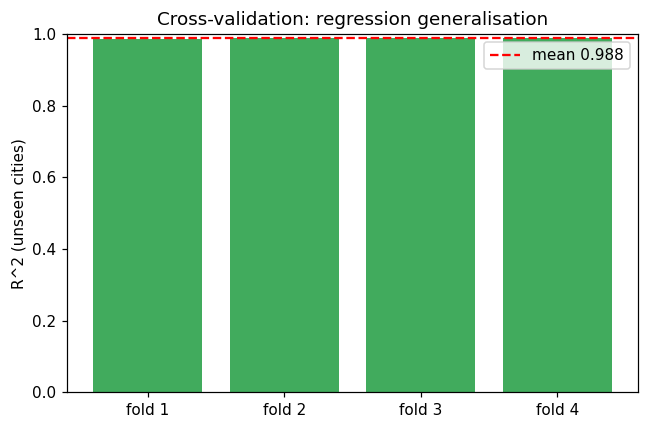

In [6]:
def make_regressor():
    return XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

# Cross-validate by CITY group: every fold is tested on unseen cities.
gkf = GroupKFold(n_splits=4)
cv_r2 = cross_val_score(make_regressor(), X_train, y_train,
                        groups=groups_train, cv=gkf, scoring="r2", n_jobs=-1)
print("GroupKFold R^2 per fold:", np.round(cv_r2, 3))
print(f"Mean CV R^2 = {cv_r2.mean():.3f}  (+/- {cv_r2.std():.3f})")

plt.figure(figsize=(6, 4))
plt.bar([f"fold {i+1}" for i in range(len(cv_r2))], cv_r2, color="#41ab5d")
plt.axhline(cv_r2.mean(), color="red", linestyle="--", label=f"mean {cv_r2.mean():.3f}")
plt.ylim(0, 1)
plt.ylabel("R^2 (unseen cities)")
plt.title("Cross-validation: regression generalisation")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Train the final regression model

In [7]:
model = make_regressor()
model.fit(X_train, y_train)
print(f"Final regression model trained on {len(X_train):,} rows.")

Final regression model trained on 153,629 rows.


## 9. Evaluate the regression on unseen cities

In [8]:
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print("Regression performance on UNSEEN cities:")
print(f"  R^2   = {r2:.3f}")
print(f"  RMSE  = ${rmse:,.0f} / month")
print(f"  MAE   = ${mae:,.0f} / month")
print(f"  (target median = ${y_test.median():,.0f} / month)")

Regression performance on UNSEEN cities:
  R^2   = 0.988
  RMSE  = $230 / month
  MAE   = $158 / month
  (target median = $5,938 / month)


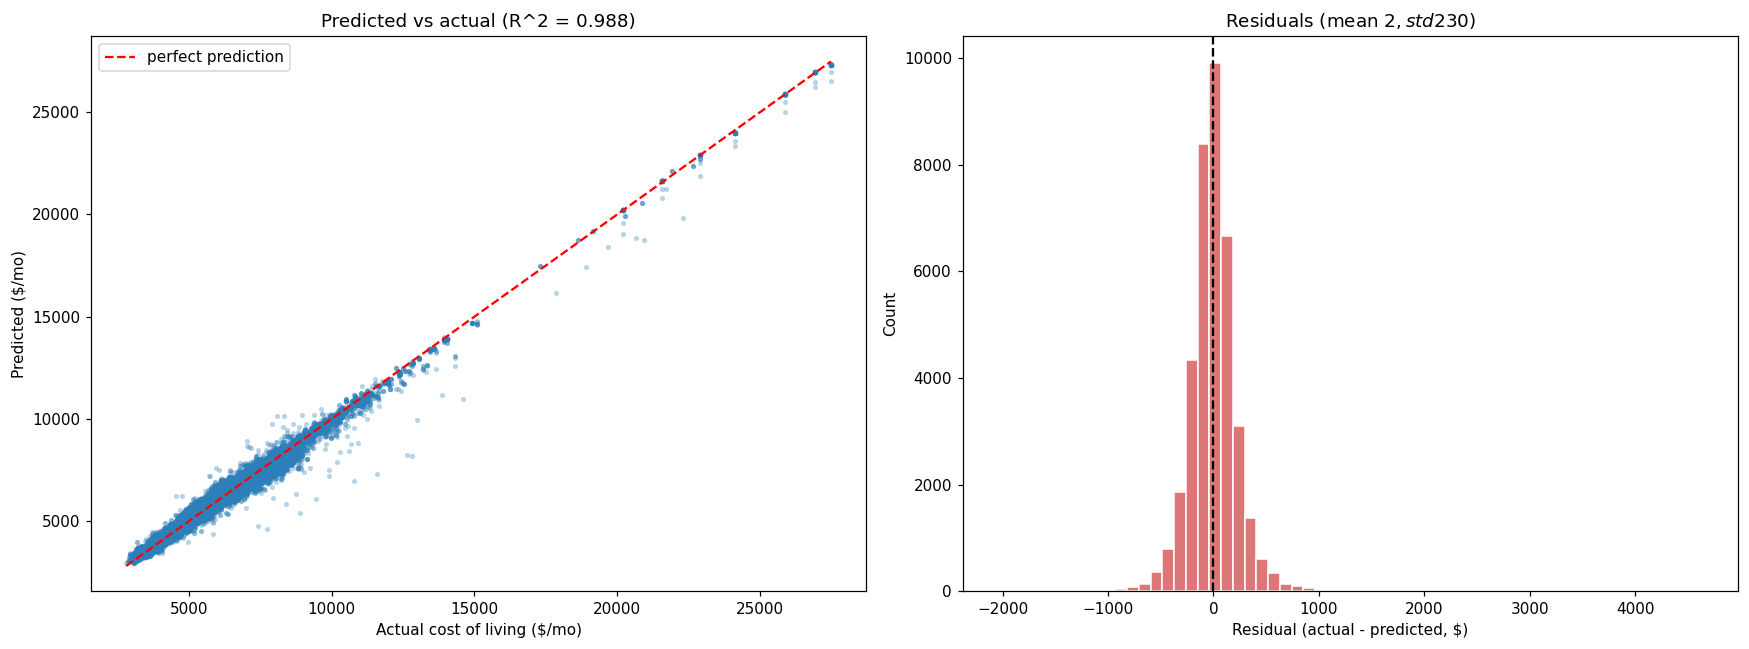

In [26]:
residuals = y_test.values - pred
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].scatter(y_test, pred, s=6, alpha=0.25, color="#2c7fb8")
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="perfect prediction")
axes[0].set_xlabel("Actual cost of living ($/mo)")
axes[0].set_ylabel("Predicted ($/mo)")
axes[0].set_title(f"Predicted vs actual (R^2 = {r2:.3f})")
axes[0].legend()

axes[1].hist(residuals, bins=60, color="#dd7777", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Residual (actual - predicted, $)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residuals (mean ${residuals.mean():,.0f}, std ${residuals.std():,.0f})")
plt.tight_layout()
plt.show()

## 10. Feature importance & the weather-risk question

Two importance views (XGBoost gain + model-agnostic permutation importance), plus a focused
experiment you asked for: **how much can weather / disaster risk *alone* predict cost of
living?** We train a second model on only the four risk scores and compare its R^2 to the full
model. This is an honest data-science answer rather than a guess.

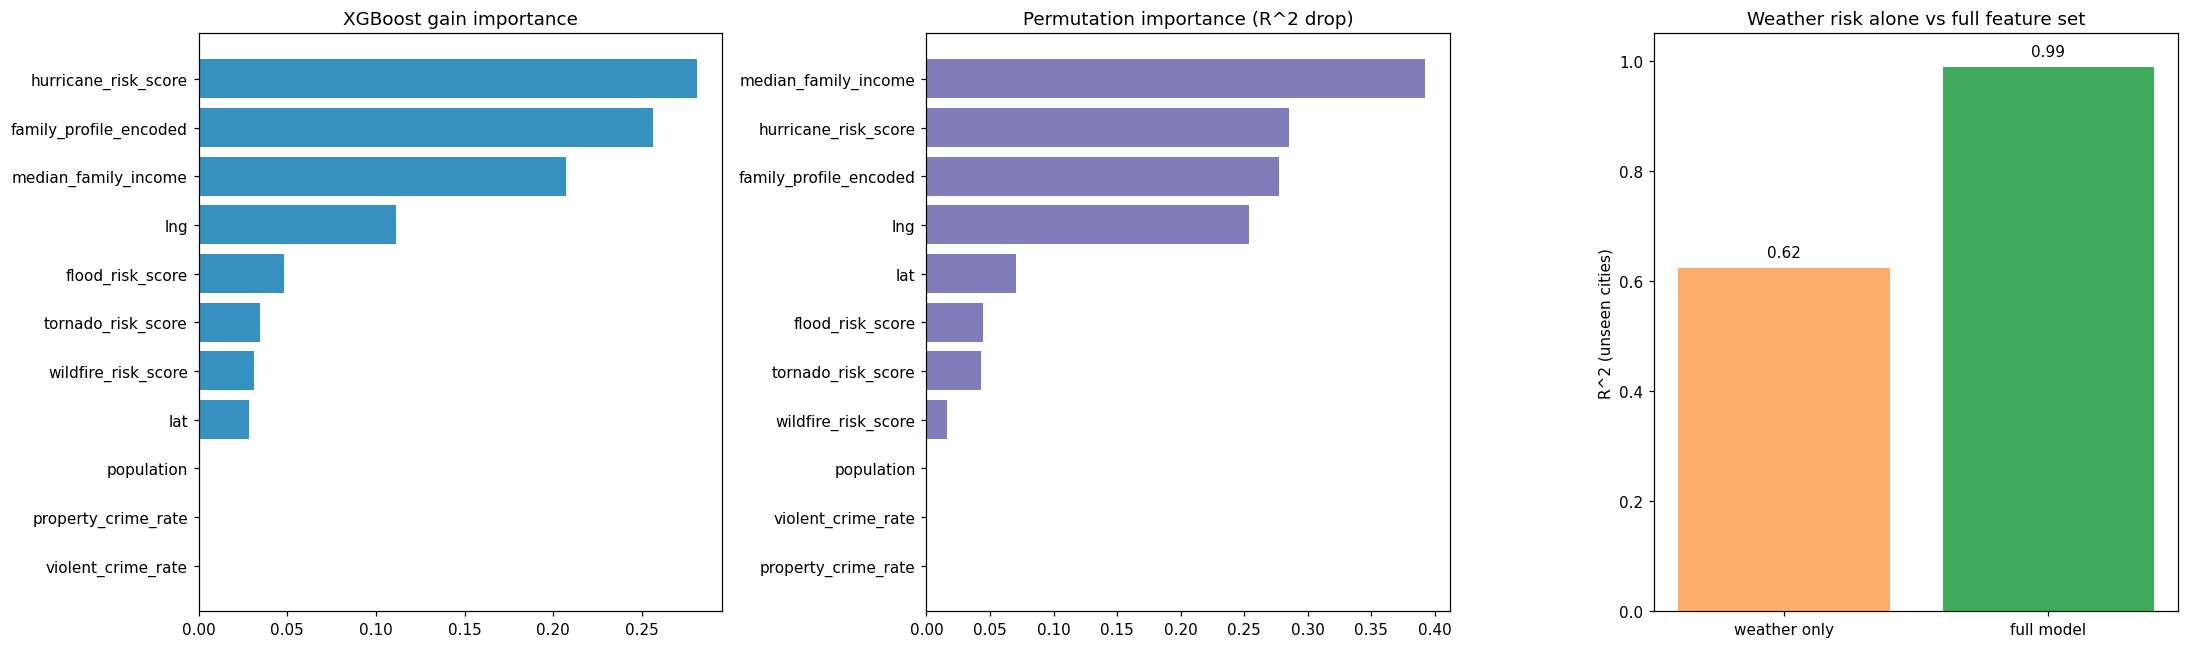

Weather / disaster risk ALONE explains R^2 = 0.623 of cost of living.
Full feature set explains R^2 = 0.988.
=> The four risk scores are a surprisingly strong proxy because they encode geography
   (hurricane -> coastal South, wildfire -> West). Adding income, location and family
   profile then lifts the model to near-perfect accuracy.


In [30]:
# --- 1. Built-in gain importance ---
gain = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()

# --- 2. Permutation importance (model-agnostic, on unseen test data) ---
sub = min(8000, len(X_test))
perm = permutation_importance(
    model, X_test.iloc[:sub], y_test.iloc[:sub],
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="r2",
)
perm_imp = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values()

# --- 3. How much can WEATHER / DISASTER RISK alone explain? ---
WEATHER_FEATURES = ["flood_risk_score", "wildfire_risk_score",
                    "hurricane_risk_score", "tornado_risk_score"]
weather_model = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=RANDOM_STATE, n_jobs=-1)
weather_model.fit(X_train[WEATHER_FEATURES], y_train)
weather_r2 = r2_score(y_test, weather_model.predict(X_test[WEATHER_FEATURES]))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].barh(gain.index, gain.values, color="#3690c0")
axes[0].set_title("XGBoost gain importance")
axes[1].barh(perm_imp.index, perm_imp.values, color="#807dba")
axes[1].set_title("Permutation importance (R^2 drop)")
axes[2].bar(["weather only", "full model"], [weather_r2, r2],
            color=["#fdae6b", "#41ab5d"])
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("R^2 (unseen cities)")
axes[2].set_title("Weather risk alone vs full feature set")
for i, v in enumerate([weather_r2, r2]):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

print(f"Weather / disaster risk ALONE explains R^2 = {weather_r2:.3f} of cost of living.")
print(f"Full feature set explains R^2 = {r2:.3f}.")
print("=> The four risk scores are a surprisingly strong proxy because they encode geography")
print("   (hurricane -> coastal South, wildfire -> West). Adding income, location and family")
print("   profile then lifts the model to near-perfect accuracy.")

## 11. Affordability classifier (real "can they afford it?" ML)

Instead of subtracting numbers, we **train** a classifier to learn the affordability decision
from city characteristics + a household income. Because the cost of living is *not* an input, the
model has to learn the cost structure implicitly. Its predicted probability becomes the
affordability score.

In [31]:
clf = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1,
)
clf.fit(X_train, yc_train)
print("Affordability classifier trained.")
print(f"Train affordable rate: {yc_train.mean():.1%} | Test affordable rate: {yc_test.mean():.1%}")

Affordability classifier trained.
Train affordable rate: 48.9% | Test affordable rate: 49.3%


## 12. Classifier evaluation

Accuracy and ROC-AUC on unseen cities, with a confusion matrix and ROC curve.

Accuracy = 0.981 | ROC-AUC = 0.998

                precision    recall  f1-score   support

not affordable       0.98      0.98      0.98     19500
    affordable       0.98      0.98      0.98     18958

      accuracy                           0.98     38458
     macro avg       0.98      0.98      0.98     38458
  weighted avg       0.98      0.98      0.98     38458



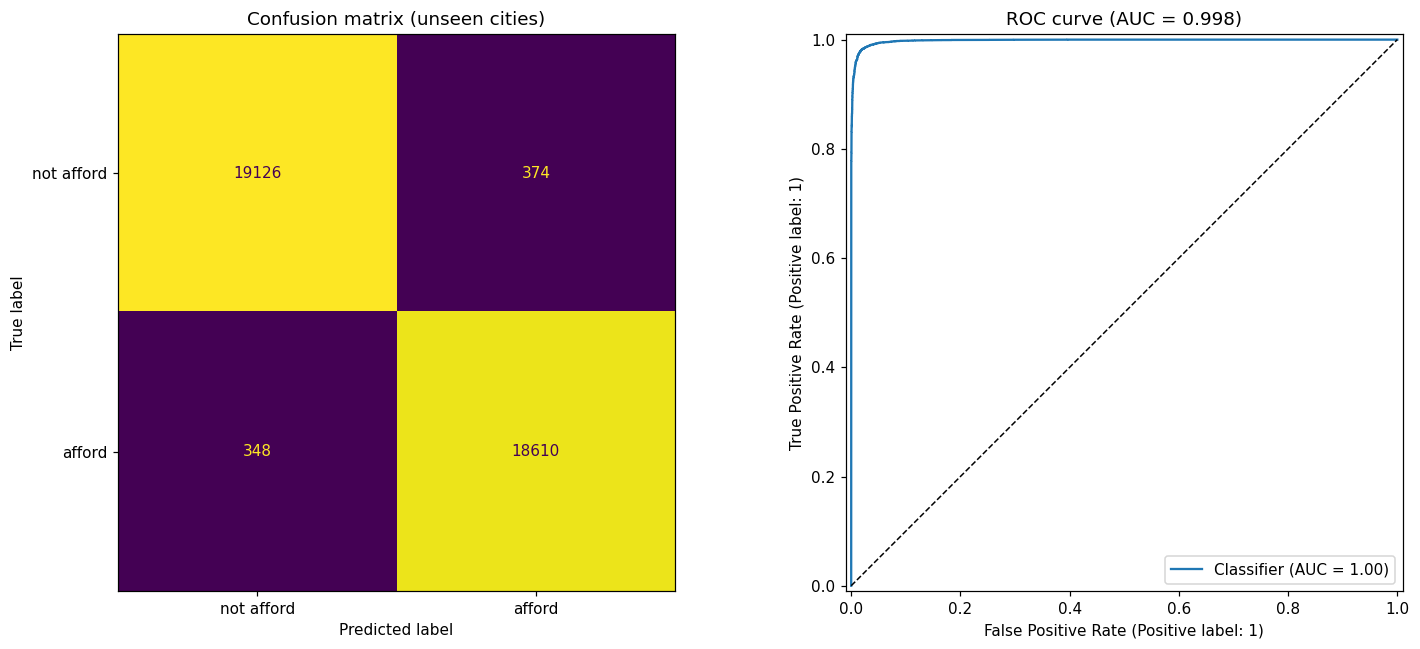

In [32]:
proba = clf.predict_proba(X_test)[:, 1]
pred_label = (proba >= 0.5).astype(int)
auc = roc_auc_score(yc_test, proba)
acc = (pred_label == yc_test.values).mean()
print(f"Accuracy = {acc:.3f} | ROC-AUC = {auc:.3f}\n")
print(classification_report(yc_test, pred_label,
                            target_names=["not affordable", "affordable"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(
    yc_test, pred_label, display_labels=["not afford", "afford"],
    ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (unseen cities)")
RocCurveDisplay.from_predictions(yc_test, proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title(f"ROC curve (AUC = {auc:.3f})")
plt.tight_layout()
plt.show()

## 13. Affordability score, cost-of-living index & saved models

`assess_city()` runs **both** models for a user's monthly income and returns the predicted cost,
an ML-derived affordability score (0-100) and a verdict. We also build a cost-of-living index
(percentile of predicted cost) and save both models + the feature schema for the FastAPI backend.

In [35]:
# Cost-of-living index: percentile rank (0-100) of each row's predicted cost.
model_df["predicted_cost"] = model.predict(model_df[FEATURE_COLS])
model_df["col_index"] = model_df["predicted_cost"].rank(pct=True) * 100
print("Cost-of-living index summary (0 = cheapest, 100 = most expensive):")
print(model_df["col_index"].describe().round(1))


def assess_city(feature_row, user_monthly_income):
    """Run BOTH models for one city + a user's monthly take-home income.

    Cost of living is a property of the CITY, so it is predicted from the city's real
    characteristics (including its area median income). The affordability classifier then
    uses the USER's income as the household budget. Returns predicted cost, an ML
    affordability score (0-100) and a verdict.
    """
    base = pd.DataFrame([feature_row])[FEATURE_COLS].copy()
    predicted_cost = float(model.predict(base)[0])

    budget_row = base.copy()
    budget_row["median_family_income"] = user_monthly_income * 12.0
    afford_prob = float(clf.predict_proba(budget_row)[0, 1])

    surplus = user_monthly_income - predicted_cost
    score = round(afford_prob * 100, 1)  # ML-based affordability score
    if score >= 70:
        verdict = "Affordable"
    elif score >= 40:
        verdict = "Stretched"
    else:
        verdict = "Unaffordable"
    return {
        "predicted_cost_of_living": round(predicted_cost, 2),
        "user_monthly_income": user_monthly_income,
        "monthly_surplus": round(surplus, 2),
        "affordability_score": score,
        "verdict": verdict,
    }


# Persist both models + schema for the FastAPI backend.
joblib.dump(model, "model_cost.pkl")
joblib.dump(clf, "model_afford.pkl")
feature_schema = {
    "feature_cols": FEATURE_COLS,
    "target": TARGET,
    "profile_encoding": PROFILE_ENCODING,
    "regression_metrics": {"r2": round(float(r2), 4),
                            "rmse": round(float(rmse), 2),
                            "mae": round(float(mae), 2)},
    "classifier_metrics": {"accuracy": round(float(acc), 4),
                            "roc_auc": round(float(auc), 4)},
    "note": ("cost_of_living_monthly fuses MIT non-housing costs with observed Zillow rent; "
             "features exclude all cost components to avoid leakage; XGBoost handles sparse "
             "crime/population values natively. Cost model uses the city's real median income; "
             "the affordability classifier uses the user's income as budget."),
}
with open("features.json", "w") as fobj:
    json.dump(feature_schema, fobj, indent=2)
print("\nSaved model_cost.pkl, model_afford.pkl, features.json")

Cost-of-living index summary (0 = cheapest, 100 = most expensive):
count    192087.0
mean         50.0
std          28.9
min           0.0
25%          25.0
50%          50.0
75%          75.0
max         100.0
Name: col_index, dtype: float64

Saved model_cost.pkl, model_afford.pkl, features.json


In [36]:
# Demo: pick a real unseen test city and assess it across several incomes.
sample_idx = test_idx[0]
sample = model_df.loc[sample_idx]
print(f"City: {sample['city']}, {sample['state']}  (profile {sample['family_profile']})")
print(f"Actual cost of living: ${sample['cost_of_living_monthly']:,.0f}/mo")
print(f"Cost-of-living index:  {sample['col_index']:.0f}/100\n")

features_row = sample[FEATURE_COLS].to_dict()
for income in [3000, 5000, 8000, 12000]:
    out = assess_city(features_row, income)
    print(f"Income ${income:>6,}/mo -> predicted cost ${out['predicted_cost_of_living']:>7,.0f} | "
          f"surplus ${out['monthly_surplus']:>8,.0f} | score {out['affordability_score']:>5} | {out['verdict']}")

City: houston, TX  (profile 1p0c)
Actual cost of living: $3,843/mo
Cost-of-living index:  7/100

Income $ 3,000/mo -> predicted cost $  3,832 | surplus $    -832 | score  57.0 | Stretched
Income $ 5,000/mo -> predicted cost $  3,832 | surplus $   1,168 | score  99.9 | Affordable
Income $ 8,000/mo -> predicted cost $  3,832 | surplus $   4,168 | score 100.0 | Affordable
Income $12,000/mo -> predicted cost $  3,832 | surplus $   8,168 | score 100.0 | Affordable
